# 🚢 Titanic — Survival Prediction

> Kaggle competition: [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/overview)

## Overview

On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, killing 1,502 of 2,224 passengers and crew. While survival involved some luck, certain groups had notably higher chances.

**Goal:** build a model to predict which passengers survived, using features like age, sex, and passenger class.

---

## Workflow

1. [Exploratory Data Analysis](#1-exploratory-data-analysis)
2. [Feature Engineering](#2-feature-engineering)
3. [Preprocessing Pipeline](#3-preprocessing-pipeline)
4. [Model Training & Tuning](#4-model-training--tuning)
5. [Results & Submission](#5-results--submission)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data Dictionary

| Variable | Definition | Key |
|----------|-----------|-----|
| `Survived` | Survival | 0 = No, 1 = Yes |
| `Pclass` | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| `Sex` | Sex | |
| `Age` | Age in years | |
| `SibSp` | # siblings / spouses aboard | |
| `Parch` | # parents / children aboard | |
| `Ticket` | Ticket number | |
| `Fare` | Passenger fare | |
| `Cabin` | Cabin number | |
| `Embarked` | Port of embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

---
## 1. Exploratory Data Analysis

### 1.1 Missing Values

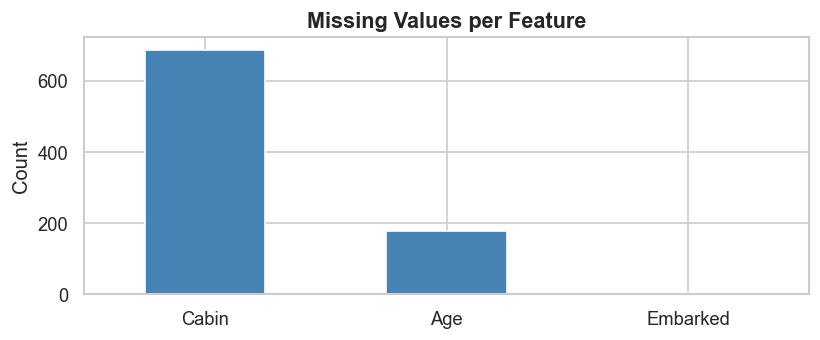

Cabin       687
Age         177
Embarked      2


In [3]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
missing.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Missing Values per Feature', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(missing.to_string())

### 1.2 Feature Distributions

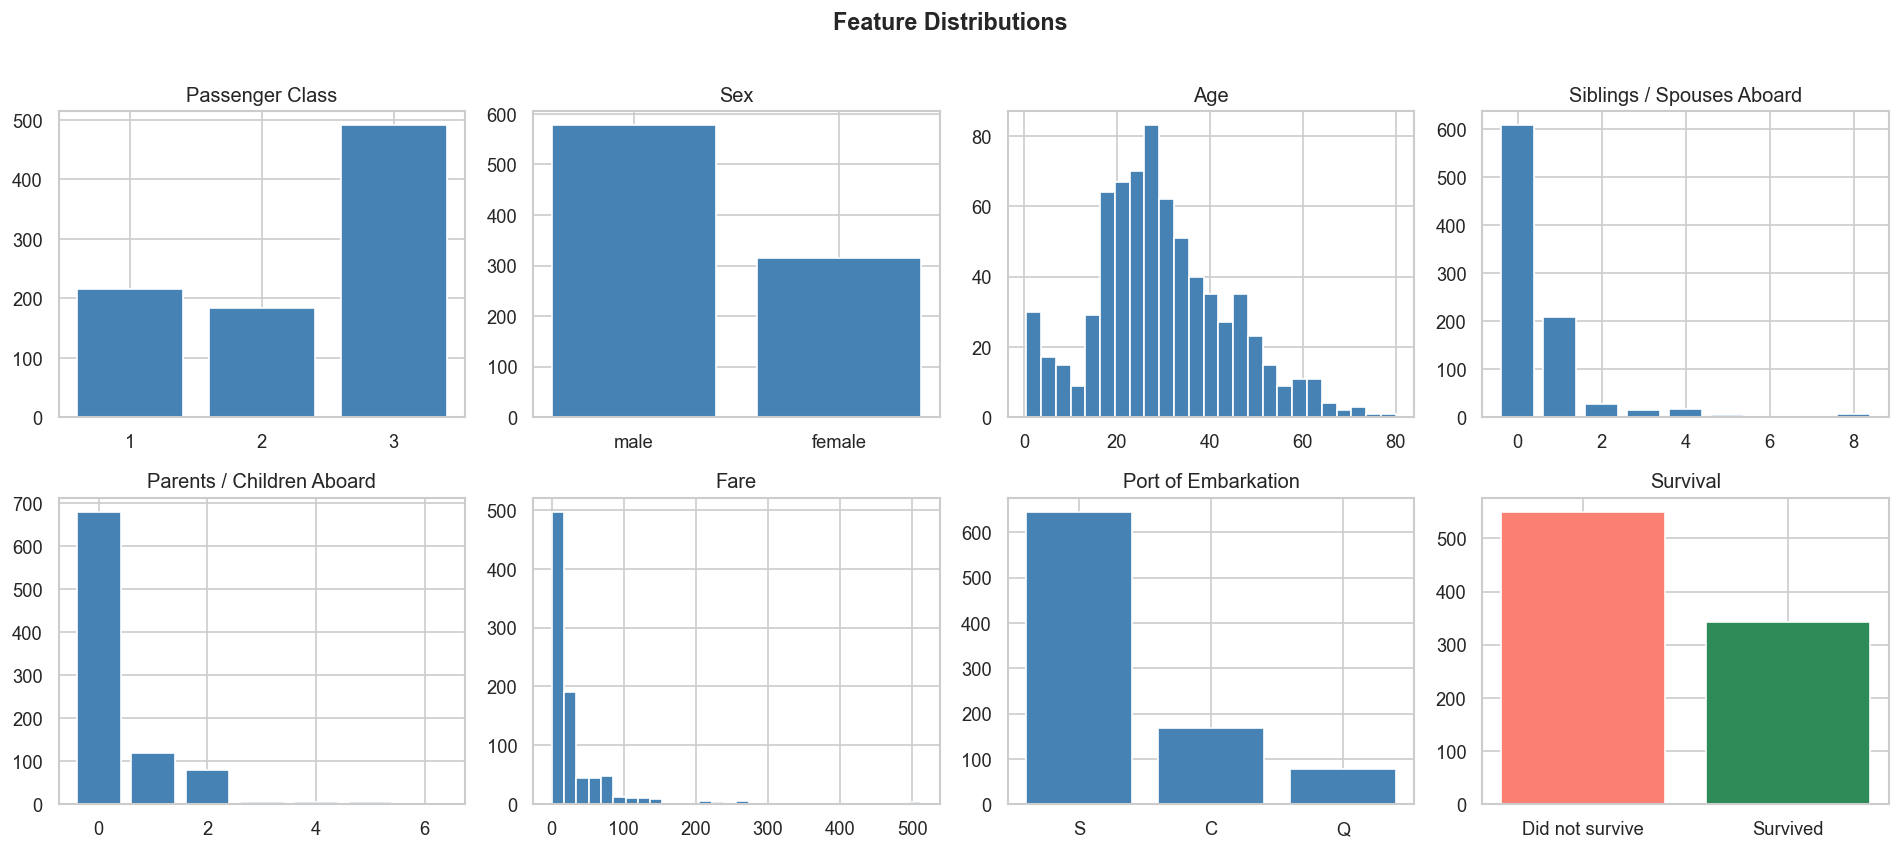

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

# Passenger Class
pclass_counts = train['Pclass'].value_counts().sort_index()
axes[0].bar(pclass_counts.index, pclass_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Passenger Class')
axes[0].set_xticks([1, 2, 3])

# Sex
sex_counts = train['Sex'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Sex')

# Age
axes[2].hist(train['Age'].dropna(), bins=25, color='steelblue', edgecolor='white')
axes[2].set_title('Age')

# SibSp
sibsp_counts = train['SibSp'].value_counts().sort_index()
axes[3].bar(sibsp_counts.index, sibsp_counts.values, color='steelblue', edgecolor='white')
axes[3].set_title('Siblings / Spouses Aboard')

# Parch
parch_counts = train['Parch'].value_counts().sort_index()
axes[4].bar(parch_counts.index, parch_counts.values, color='steelblue', edgecolor='white')
axes[4].set_title('Parents / Children Aboard')

# Fare
axes[5].hist(train['Fare'], bins=30, color='steelblue', edgecolor='white')
axes[5].set_title('Fare')

# Embarked
emb_counts = train['Embarked'].value_counts()
axes[6].bar(emb_counts.index, emb_counts.values, color='steelblue', edgecolor='white')
axes[6].set_title('Port of Embarkation')

# Survived
surv_counts = train['Survived'].value_counts().sort_index()
axes[7].bar(['Did not survive', 'Survived'], surv_counts.values,
            color=['salmon', 'seagreen'], edgecolor='white')
axes[7].set_title('Survival')

fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.3 Survival by Key Features

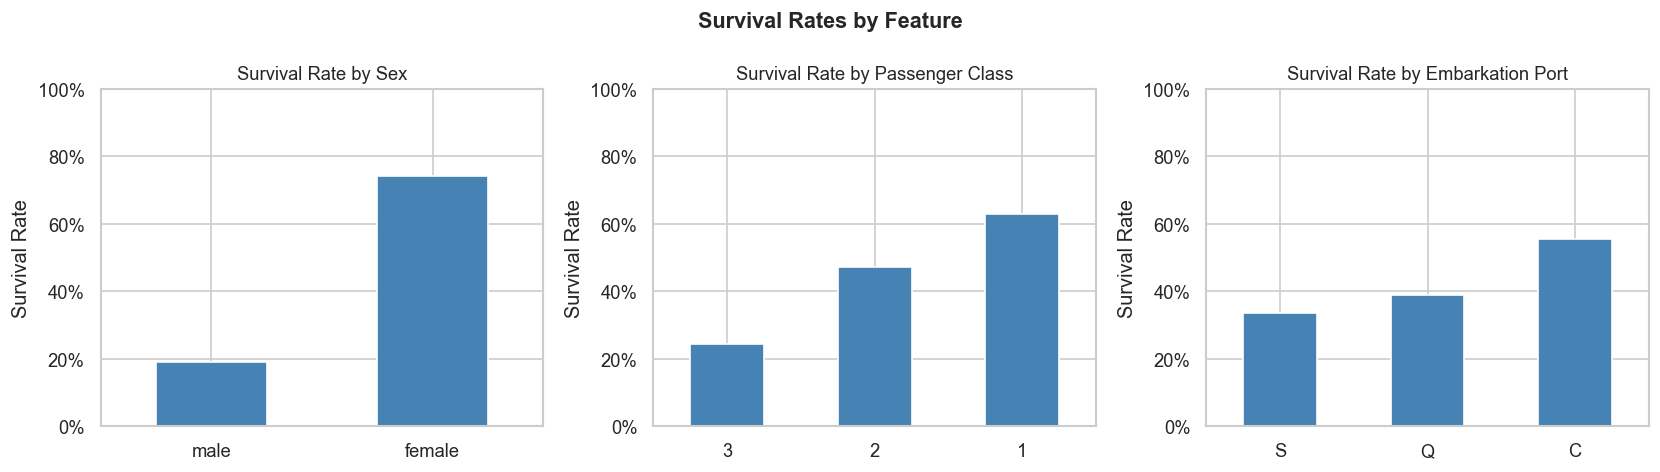

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ['Sex', 'Pclass', 'Embarked'],
    ['Survival Rate by Sex', 'Survival Rate by Passenger Class', 'Survival Rate by Embarkation Port']
):
    surv_rate = train.groupby(col)['Survived'].mean().sort_values()
    surv_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', rot=0)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_xlabel('')

fig.suptitle('Survival Rates by Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Age Distribution by Survival

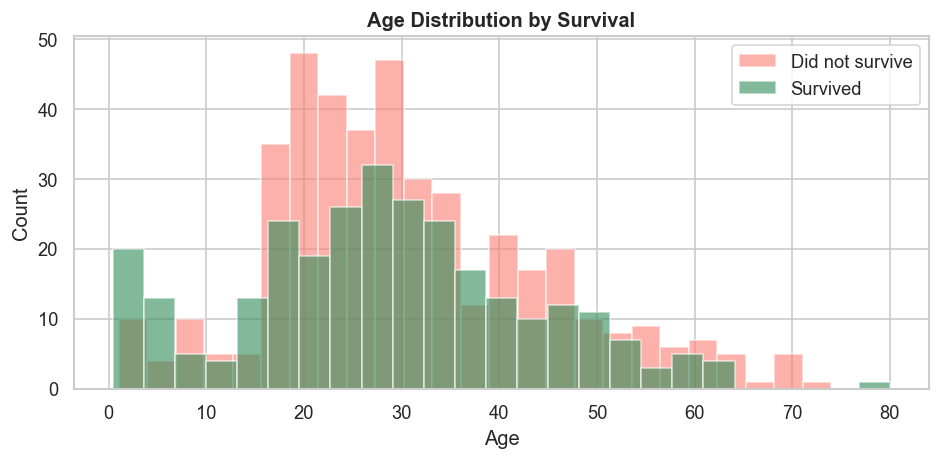

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

for survived, label, color in [(0, 'Did not survive', 'salmon'), (1, 'Survived', 'seagreen')]:
    train[train['Survived'] == survived]['Age'].dropna().plot(
        kind='hist', bins=25, alpha=0.6, ax=ax, label=label, color=color, edgecolor='white'
    )

ax.set_title('Age Distribution by Survival', fontsize=12, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

### 1.5 Correlation Matrix

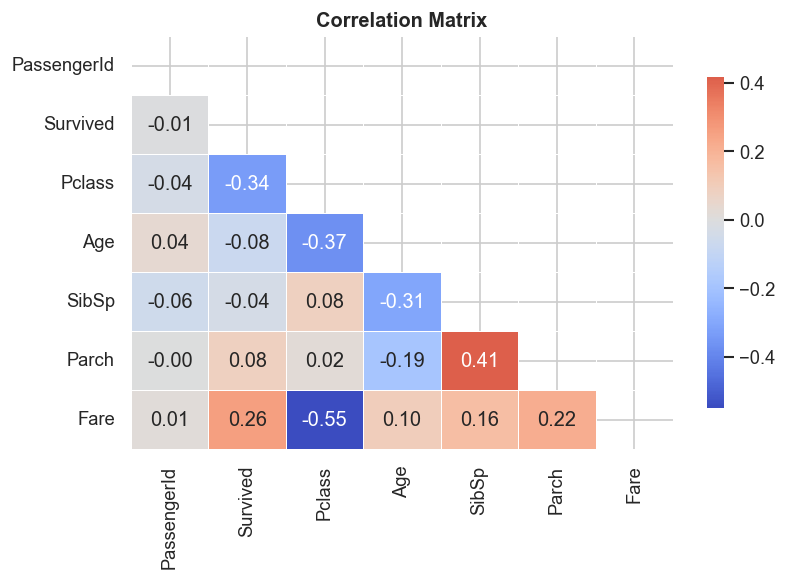

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = train.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle only

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=.5,
    ax=ax, cbar_kws={'shrink': .8}
)
ax.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights

| Finding | Detail |
|---------|--------|
| **Sex** | Women had a ~74% survival rate vs ~19% for men |
| **Passenger class** | 1st class: ~63% survival; 3rd class: ~24% |
| **Fare** | Positively correlated with survival (proxy for class/wealth) |
| **Traveling alone** | Passengers without family had lower survival rates |
| **Age** | Children had slightly higher survival rates |

---
## 2. Feature Engineering

Custom features capture hidden patterns not present in the raw data:

| Feature | Rationale |
|---------|----------|
| `FamilySize` | Family members may have coordinated during evacuation |
| `IsAlone` | Solo passengers may have had different survival behavior |

In [8]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Creates new features from existing columns."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
        X['IsAlone'] = (X['FamilySize'] == 1).astype(int)
        return X

### Validating New Features

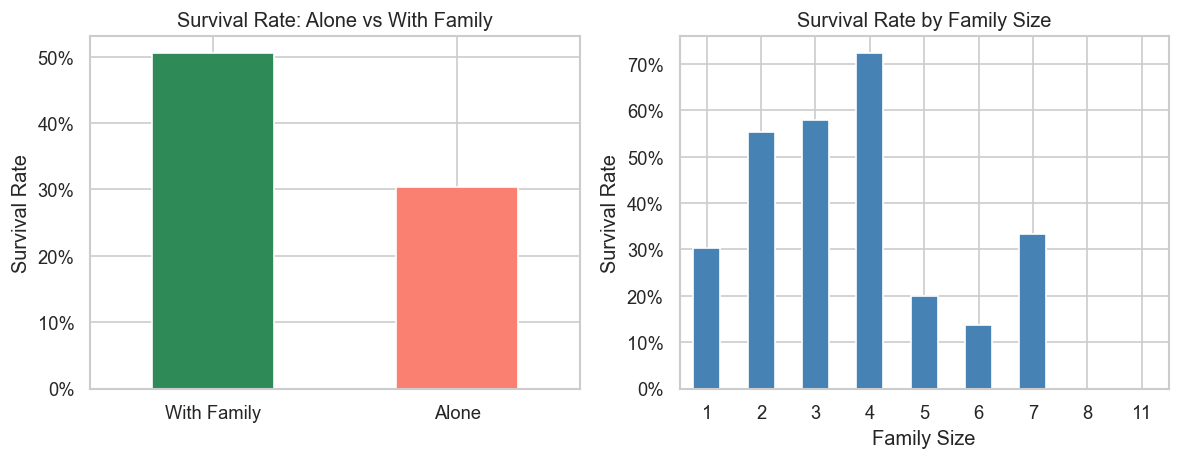

In [9]:
# Quick check on the training set
train_feat = train.copy()
train_feat['FamilySize'] = train_feat['SibSp'] + train_feat['Parch'] + 1
train_feat['IsAlone'] = (train_feat['FamilySize'] == 1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# IsAlone vs Survival
surv_alone = train_feat.groupby('IsAlone')['Survived'].mean()
surv_alone.index = ['With Family', 'Alone']
surv_alone.plot(kind='bar', ax=axes[0], color=['seagreen', 'salmon'], edgecolor='white', rot=0)
axes[0].set_title('Survival Rate: Alone vs With Family')
axes[0].set_ylabel('Survival Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_xlabel('')

# FamilySize vs Survival
surv_famsize = train_feat.groupby('FamilySize')['Survived'].mean()
surv_famsize.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', rot=0)
axes[1].set_title('Survival Rate by Family Size')
axes[1].set_ylabel('Survival Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].set_xlabel('Family Size')

plt.tight_layout()
plt.show()

---
## 3. Preprocessing Pipeline

Using `sklearn.pipeline.Pipeline` to:
- **Avoid data leakage** — all transformations are fitted on training data only
- **Simplify code** — single `.fit()` / `.predict()` call
- **Enable safe cross-validation** — no risk of contamination between folds

```
Input
 └─▶ FeatureEngineer        (add FamilySize, IsAlone)
      └─▶ ColumnTransformer
           ├─▶ Categorical   → OneHotEncoder  (Sex, Embarked, IsAlone)
           └─▶ Numerical     → SimpleImputer  (Age, Fare, Pclass)
                └─▶ RandomForestClassifier
```

In [10]:
# ── Feature groups ───────────────────────────────────────────────────────────
CATEGORICAL = ['Sex', 'Embarked', 'IsAlone']
NUMERICAL   = ['Age', 'Fare', 'Pclass']

# ── Transformers ─────────────────────────────────────────────────────────────
cat_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_transformer, CATEGORICAL),
    ('num', num_transformer, NUMERICAL),
])

# ── Full pipeline ─────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('engineer',     FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('clf',          RandomForestClassifier(random_state=42)),
])

---
## 4. Model Training & Tuning

**Why Random Forest?**  
- Handles non-linear relationships and feature interactions naturally  
- Robust to outliers and noisy features  
- Requires no feature scaling  
- Generally strong baseline on tabular/structured data

**Hyperparameter search** via 5-fold `GridSearchCV`:

| Parameter | Values tested |
|-----------|---------------|
| `n_estimators` | 10, 100, 200 |
| `max_depth` | 4, 5, 8, None |

In [11]:
X = train.drop('Survived', axis=1)
y = train['Survived']

param_grid = {
    'clf__n_estimators': [10, 100, 200],
    'clf__max_depth':    [4, 5, 8, None],
}

gs = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
gs.fit(X, y)

print(f'Best parameters : {gs.best_params_}')
print(f'Best CV accuracy: {gs.best_score_:.4f} ({gs.best_score_*100:.2f}%)')

Best parameters : {'clf__max_depth': 8, 'clf__n_estimators': 100}
Best CV accuracy: 0.8261 (82.61%)


### Cross-Validation Results

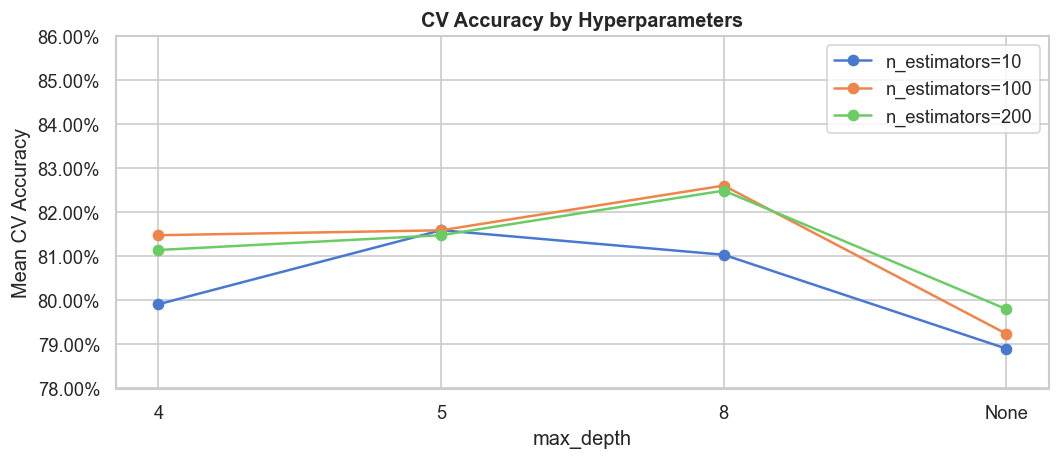

In [12]:
results = pd.DataFrame(gs.cv_results_)
results['max_depth_label'] = results['param_clf__max_depth'].fillna('None').astype(str)

fig, ax = plt.subplots(figsize=(9, 4))

for n_est in param_grid['clf__n_estimators']:
    subset = results[results['param_clf__n_estimators'] == n_est]
    ax.plot(
        subset['max_depth_label'],
        subset['mean_test_score'],
        marker='o', label=f'n_estimators={n_est}'
    )

ax.set_title('CV Accuracy by Hyperparameters', fontsize=12, fontweight='bold')
ax.set_xlabel('max_depth')
ax.set_ylabel('Mean CV Accuracy')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2%}'))
ax.set_ylim(0.78, 0.86)
plt.tight_layout()
plt.show()

### Feature Importances

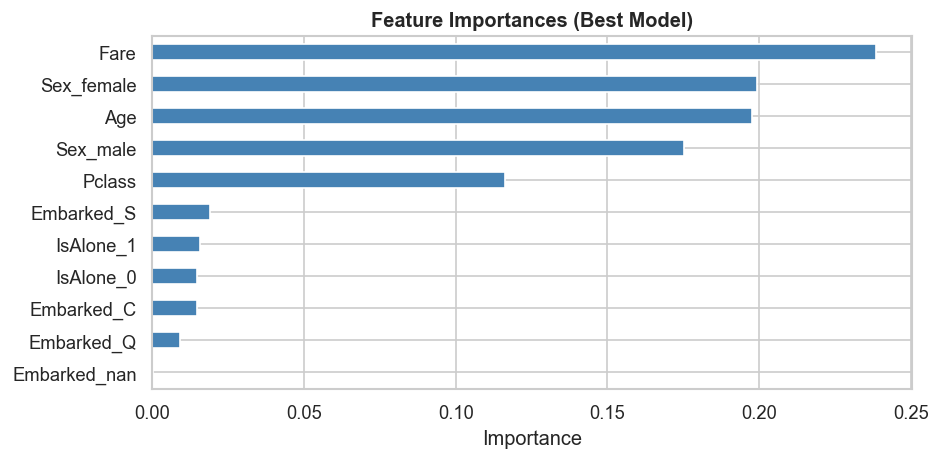

In [13]:
best_pipeline = gs.best_estimator_
rf_model = best_pipeline.named_steps['clf']
cat_features = best_pipeline.named_steps['preprocessor'] \
                             .named_transformers_['cat'] \
                             .named_steps['onehot'] \
                             .get_feature_names_out(CATEGORICAL).tolist()
feature_names = cat_features + NUMERICAL

importances = pd.Series(rf_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importances (Best Model)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 5. Results & Submission

In [14]:
predictions = gs.predict(test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived':    predictions
})

submission.to_csv('submission.csv', index=False)

print('Submission saved to submission.csv')
print(f"Predicted survivors: {predictions.sum()} / {len(predictions)} ({predictions.mean():.1%})")
submission.head()

Submission saved to submission.csv
Predicted survivors: 141 / 418 (33.7%)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


---
## Summary

| Step | Choice | Reason |
|------|--------|--------|
| Missing values | Median imputation | Robust to outliers in Age/Fare |
| Categorical encoding | One-Hot Encoding | No ordinal relationship assumed |
| Feature engineering | `FamilySize`, `IsAlone` | Captures group-survival dynamics |
| Model | Random Forest | Strong on tabular data; no scaling needed |
| Tuning | 5-fold GridSearchCV | Prevents data leakage across folds |
| Best CV accuracy | **~82.3%** | `max_depth=8`, `n_estimators=100` |

### Possible Next Steps

- Extract `Title` from passenger name (Mr., Mrs., Miss., etc.)
- Bin `Age` and `Fare` into categorical groups
- Try other models: XGBoost, LightGBM, or a voting ensemble
- Use `StratifiedKFold` for more stable cross-validation estimates